In [1]:
import scipy as sp
from scipy.special import jv, hankel2, yv, spherical_jn, spherical_yn
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, heaviside, exp, sin, cos
from utils import e_r_cpa_numerator, e_r_cpa, hl2, hl2prime, hl1, hl1prime, e_r_recursive_cpa
from refractiveindex import RefractiveIndexMaterial

## This notebook concerns the paper [Causality relations in the homogenization of metamaterials](https://journals.aps.org/prb/pdf/10.1103/PhysRevB.84.054305?casa_token=4f21nymi9rIAAAAA%3AFQXPLXASOiUj-PXAmIum1JlwFggxSD5gFvi7e0Wx836uvSvYz3iwo8bwIpZZoSLACPKvtWAog3tjyg) by Andrea Alu

### We first do Figure 1

In [4]:
# We define alpha_s (which is actually a^(-3)alpha_s), where alpha_s is defined in Equation 15 of the paper
# Note that k_0 here is actually the dimensionless quantity k_0a
def alpha_s(k_0, x):
    return ((6*pi)/k_0**3)/(1/(k_0*x)**3-1j)

# We define alpha_d (which is actually alpha_d/a^3), where alpha_d is the fully retarded polarizability, defined in Equation 7 of the paper
def alpha_d(k_0, epsilon):
    k = k_0*sqrt(epsilon)
    k0j_lprime = spherical_jn(1, k_0) + k_0*spherical_jn(1, k_0, derivative = True)
    k0y_lprime = spherical_yn(1, k_0) + k_0*spherical_yn(1, k_0, derivative = True)
    kj_lprime = spherical_jn(1, k) + k*spherical_jn(1, k, derivative = True)

    u = spherical_jn(1, k)*k0j_lprime - spherical_jn(1, k_0)*kj_lprime/epsilon
    v = spherical_jn(1, k)*k0y_lprime - spherical_yn(1, k_0)*kj_lprime/epsilon
    return (6*pi/k_0**3)/(v/u-1j)

# alpha_s in the time domain (normalized by 2*pi*c*x^2*a^2 in accordance with Figure 2)
# Note that t here is actually the dimensionless quantity ct/2a
def alpha_st(t, x):
    causal_component = exp(-t/x)*(cos(sqrt(3)*t/x) + sqrt(3)*sin(sqrt(3)*t/x))
    non_causal_component = exp(2*t/x)
    return heaviside(t, 0.5)*causal_component + heaviside(-t, 0.5)*non_causal_component

# returns x, as defined in the paper (we take epsilon_0=1)
def return_x(epsilon):
    x_cubed = (2/3)*(epsilon-1)/(epsilon+2)
    return x_cubed**(1/3)

In [9]:
epsilon_1 = 3
epsilon_2 = 20
x_1 = return_x(epsilon_1)
x_2 = return_x(epsilon_2) # These are the two values used in Figure 1

In [10]:
N = 10000
k_0_s = linspace(0.01, 8, N)
alpha_s_1 = alpha_s(k_0_s, x_1)
alpha_s_2 = alpha_s(k_0_s, x_2)

alpha_d_1 = alpha_d(k_0_s, epsilon_1)
alpha_d_2 = alpha_d(k_0_s, epsilon_2)

print("Max Re(alpha_s_1): ", alpha_s_1.real.max().round(3))
print("Max Im(alpha_s_1): ", alpha_s_1.imag.max().round(3))
print("Max Re(alpha_s_2): ", alpha_s_2.real.max().round(3))
print("Max Im(alpha_s_2): ", alpha_s_2.imag.max().round(3))

Max Re(alpha_s_1):  5.027
Max Im(alpha_s_1):  2.513
Max Re(alpha_s_2):  10.853
Max Im(alpha_s_2):  5.426


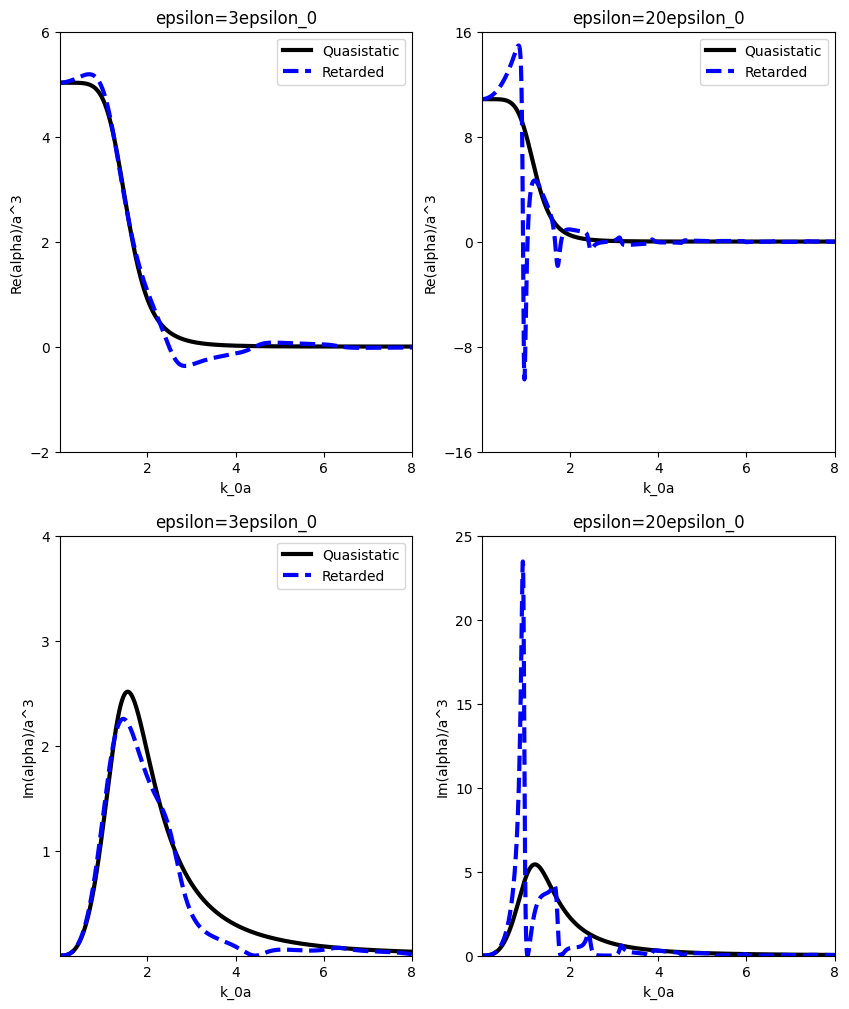

In [30]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 12))
ax1.plot(k_0_s, alpha_s_1.real, color="black", linewidth=3, label="Quasistatic")
ax1.plot(k_0_s, alpha_d_1.real, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax1.legend()
ax1.set_xlim(k_0_s.min(), k_0_s.max());
ax1.set_ylim(-2, 6);
ax1.set_xticks(linspace(2, 8, 4));
ax1.set_yticks(linspace(-2, 6, 5));
ax1.set_title("epsilon=3epsilon_0")
ax1.set_xlabel("k_0a")
ax1.set_ylabel("Re(alpha)/a^3")

ax2.plot(k_0_s, alpha_s_2.real, color="black", linewidth=3, label="Quasistatic")
ax2.plot(k_0_s, alpha_d_2.real, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax2.legend()
ax2.set_xlim(k_0_s.min(), k_0_s.max());
ax2.set_ylim(-16, 16)
ax2.set_xticks(linspace(2, 8, 4));
ax2.set_yticks(linspace(-16, 16, 5))
ax2.set_title("epsilon=20epsilon_0");
ax2.set_xlabel("k_0a");
ax2.set_ylabel("Re(alpha)/a^3")

ax3.plot(k_0_s, alpha_s_1.imag, color="black", linewidth=3, label="Quasistatic")
ax3.plot(k_0_s, alpha_d_1.imag, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax3.legend();
ax3.set_xlim(k_0_s.min(), k_0_s.max());
ax3.set_ylim(0, 4);
ax3.set_yticks(linspace(1, 4, 4))
ax3.set_xticks(linspace(2, 8, 4));
ax3.set_xlabel("k_0a")
ax3.set_ylabel("Im(alpha)/a^3")
ax3.set_title("epsilon=3epsilon_0")

ax4.plot(k_0_s, alpha_s_2.imag, color="black", linewidth=3, label="Quasistatic")
ax4.plot(k_0_s, alpha_d_2.imag, color="blue", linewidth=3, linestyle="dashed", label="Retarded")
ax4.set_ylim(0, 25)
ax4.set_xlim(k_0_s.min(), k_0_s.max());
ax4.set_xticks(linspace(2, 8, 4));
ax4.set_xlabel("k_0a");
ax4.set_ylabel("Im(alpha)/a^3")
ax4.set_title("epsilon=20epsilon_0");

### Now we do Figure 2

In [86]:
N = 10000
t_s = linspace(-2, 10, N) # range of time for Figure 2
alpha_st_1 = alpha_st(t_s, x_1);
alpha_st_2 = alpha_st(t_s, x_2);
print("Max value of alpha_st_1: ", alpha_st_1.max().round(3))
print("Min value of alpha_st_1: ", alpha_st_1.min().round(3))
print("Max value of alpha_st_2: ", alpha_st_2.max().round(3))
print("Min value of alpha_st_2: ", alpha_st_2.min().round(3))

Max value of alpha_st_1:  1.28
Min value of alpha_st_1:  -0.209
Max value of alpha_st_2:  1.28
Min value of alpha_st_2:  -0.209


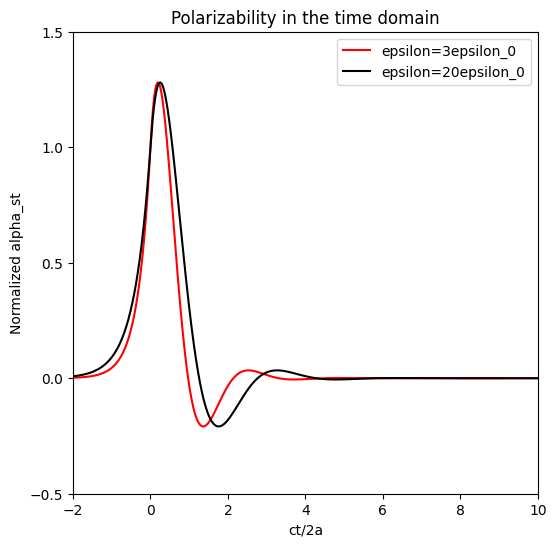

In [85]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(t_s, alpha_st_1, color="red", label="epsilon=3epsilon_0")
ax.plot(t_s, alpha_st_2, color="black", label="epsilon=20epsilon_0");
ax.legend();
ax.set_xlim(t_s.min(), t_s.max());
ax.set_yticks(linspace(-0.5, 1.5, 5))
ax.set_ylim(-0.5, 1.5);
ax.set_xlabel("ct/2a")
ax.set_ylabel("Normalized alpha_st");
ax.set_title("Polarizability in the time domain");